In [332]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from utilsCPD import *

def make_dynamic_blobs(n_samples, base_center, n_clusters, varying_features, 
                       cluster_std=1.0, center_offset_range=(-5, 5), 
                       distribution="normal", random_state=None):
    """
    Generate synthetic data with dynamic centers and feature-wise distributions.
    
    Parameters:
        n_samples: int
            Total number of samples.
        base_center: array-like, shape (n_features,)
            Center of the base cluster.
        n_clusters: int
            Number of clusters to generate.
        varying_features: list of int
            Indices of features that vary across clusters.
        cluster_std: float or array-like
            Std dev for distributions. Can be a scalar or array of shape (n_features,).
        center_offset_range: tuple
            Uniform offset range applied to varying features.
        distribution: str or list of str
            Single distribution name or list of length n_features specifying distribution per feature.
        random_state: int or None
            Seed for reproducibility.
    
    Returns:
        X: ndarray (n_samples, n_features)
        y: ndarray (n_samples,)
        centers: ndarray (n_clusters, n_features)
    """
    if random_state is not None:
        np.random.seed(random_state)
    
    base_center = np.array(base_center, dtype=float)
    n_features = len(base_center)
    
    if isinstance(distribution, str):
        distribution = [distribution] * n_features
    elif isinstance(distribution, list):
        if len(distribution) != n_features:
            raise ValueError("Length of distribution list must match number of features.")

    if np.isscalar(cluster_std):
        cluster_std = np.full(n_features, cluster_std)

    samples_per_cluster = n_samples // n_clusters
    remainder = n_samples % n_clusters

    # Generate cluster centers
    centers = [base_center.copy()]
    offsets = {}
    for _ in range(1, n_clusters):
        new_center = base_center.copy()
        for feat in varying_features:
            c = np.random.uniform(*center_offset_range)
            new_center[feat] += c
            offsets[feat] = c
        centers.append(new_center)
    centers = np.array(centers)

    # Generate data
    X = []
    y = []

    for cluster_idx, center in enumerate(centers):
        cluster_size = samples_per_cluster + (1 if cluster_idx < remainder else 0)
        cluster_points = np.zeros((cluster_size, n_features), dtype=np.float32)

        for feat_idx in range(n_features):
            dist = distribution[feat_idx]
            std = cluster_std[feat_idx]
            loc = center[feat_idx]

            if dist == "normal":
                vals = np.random.normal(loc=loc, scale=std, size=cluster_size)
            elif dist == "uniform":
                vals = np.random.uniform(low=loc - std, high=loc + std, size=cluster_size)
            elif dist == "laplace":
                vals = np.random.laplace(loc=loc, scale=std, size=cluster_size)
            elif dist == "exponential":
                vals = np.random.exponential(scale=std, size=cluster_size) + loc
            elif dist == "beta":
                vals = np.random.beta(a=2, b=5, size=cluster_size) * std + loc
            elif dist == "gamma":
                vals = np.random.gamma(shape=2, scale=std, size=cluster_size) + loc
            else:
                raise ValueError(f"Unsupported distribution: {dist}")

            cluster_points[:, feat_idx] = vals
        
        X.append(cluster_points)
        y.extend([cluster_idx] * cluster_size)

    return np.vstack(X), np.array(y), centers, offsets


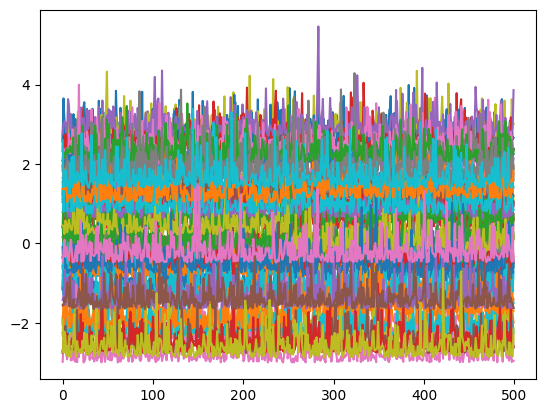

In [333]:
# Base center for the clusters
base_center = list(np.random.uniform(-3, 3, 50))  
n_clusters = 2
n_samples = 500
np.random.seed(0)
varying_features = np.random.choice(50,10,replace=False)  

# Generate dataset with Laplace distribution (heavy tails)
X, y, centers,_ = make_dynamic_blobs(
    n_samples=n_samples, 
    base_center=base_center, 
    n_clusters=n_clusters, 
    varying_features=varying_features, 
    cluster_std=0.30, 
    center_offset_range=(-0.5, 0.5), 
    distribution=["normal"] * 0 + ["exponential"] * 50,
    random_state=42
)

# Plot the results
fig, ax = plt.subplots()
pd.DataFrame(X).plot(ax=ax, legend=False)
plt.show()


In [316]:
import ruptures as rpt


algo_c = rpt.KernelCPD(kernel="rbf", min_size=1).fit(
        np.array(X)
    ) 
penalty_value = 1# beta
cps_KCPA_PELT = algo_c.predict(pen=penalty_value)
cps = np.array(cps_KCPA_PELT)[:-1]
cps

array([250])

In [4]:
import torch

In [317]:
x_tensor = torch.Tensor(X[:250,:])
y_tensor = torch.Tensor(X[250:,:])
rf, cont = remove_important_features_syn(x_tensor,y_tensor,10,1000,q=0.90)

In [334]:
from SWCPD import BaseDetector as SWDCP
import ruptures as rpt

METRICS = {}

for err in [0.2,0.3,0.5,0.7,1.0,2.0]:
    METRICS[err] = {'Acc_removal':[], 'AUC_Drop':[],'COV_Drop':[],'F1_Drop':[]}
    for seed in [1,2,3,4,5,6]:

        base_center = list(np.random.uniform(-10, 3, 50))  
        n_clusters = 2
        n_samples = 500
        #np.random.seed(0)
        varying_features = np.random.choice(50,10,replace=False)  

        # Generate dataset with Laplace distribution (heavy tails)
        X, y, centers, offets = make_dynamic_blobs(
            n_samples=n_samples, 
            base_center=base_center, 
            n_clusters=n_clusters, 
            varying_features=varying_features, 
            cluster_std=0.3, 
            center_offset_range=(-err, err), 
            distribution=["normal"] * 25 + ["exponential"] * 25,
            random_state=seed
        )
        detector = SWDCP(data=X,window_length=50,max_history=50,significance=0.01)

        algo_c = rpt.KernelCPD(kernel="rbf", min_size=1).fit(
                np.array(X)
            ) 
        penalty_value = 1# beta
        cps_KCPA_PELT = algo_c.predict(pen=penalty_value)
        cps = np.array(cps_KCPA_PELT)[:-1]
        #print(cps)
        GT = [250]
        detector.change_points['loc'] = cps
        f1,cov,auc,_,_ = detector.evaluate(GT,10) ##detector.evaluate(GT,10)

        x_tensor = torch.Tensor(X[:250,:])
        y_tensor = torch.Tensor(X[250:,:])
        rf, cont = remove_important_features_syn(x_tensor,y_tensor,10,1000,q=0.95)

        remove_ind = []

        for removal in rf:
            #print(f"feature removes {removal['removed_feature']} and beta {removal['beta']}")
            if removal['removed_feature'] not in remove_ind:
                remove_ind.append(removal['removed_feature'])


        keep_index = [i for i in range(X.shape[1])]
        for i in remove_ind:
            keep_index.remove(i)
        X_mask = X[:,keep_index]

        algo_c = rpt.KernelCPD(kernel="rbf", min_size=1).fit(
                np.array(X_mask)
            ) 
        penalty_value = 1
        cps_KCPA_PELT = algo_c.predict(pen=penalty_value)
        cps = np.array(cps_KCPA_PELT)[:-1]
        #print(cps)

        detector.change_points['loc'] = cps
        f1_new,cov_new,auc_new,_,_ = detector.evaluate(GT,10)
        #print(cov_new)
        common_elements = set(remove_ind).intersection(set(varying_features))
        count = len(common_elements)
        METRICS[err]['Acc_removal'].append(count/len(varying_features))
        METRICS[err]['AUC_Drop'].append(auc-auc_new)
        METRICS[err]['COV_Drop'].append(cov-cov_new)
        METRICS[err]['F1_Drop'].append(f1-f1_new)
        #print(f"Correct removal {count/len(varying_features)*100}")
        #print(f"auc drop {auc} --> {auc_new}")
        #print(f"covering drop {cov} --> {cov_new}")

In [40]:
for k in METRICS.keys():
    print(k)
    print(f"Acc_removal: {np.mean(METRICS[k]['Acc_removal']):.4f} +-{np.std(METRICS[k]['Acc_removal']):.4f}  ")
    print(f"AUC_Drop: {np.mean(METRICS[k]['AUC_Drop']):.4f} +-{np.std(METRICS[k]['AUC_Drop']):.4f}  ")
    print(f"COV_Drop: {np.mean(METRICS[k]['COV_Drop']):.4f} +-{np.std(METRICS[k]['COV_Drop']):.4f}  ")


0.2
Acc_removal: 0.6833 +-0.1067  
AUC_Drop: 0.2500 +-0.0000  
COV_Drop: 0.4901 +-0.0122  
0.3
Acc_removal: 0.7667 +-0.0745  
AUC_Drop: 0.2500 +-0.0000  
COV_Drop: 0.4914 +-0.0110  
0.5
Acc_removal: 0.8667 +-0.0745  
AUC_Drop: 0.2500 +-0.0000  
COV_Drop: 0.4993 +-0.0015  
0.7
Acc_removal: 0.9000 +-0.0816  
AUC_Drop: 0.2500 +-0.0000  
COV_Drop: 0.4993 +-0.0015  
1.0
Acc_removal: 0.9000 +-0.0816  
AUC_Drop: 0.2500 +-0.0000  
COV_Drop: 0.5000 +-0.0000  
2.0
Acc_removal: 0.9500 +-0.0764  
AUC_Drop: 0.2500 +-0.0000  
COV_Drop: 0.5000 +-0.0000  


|$\delta$ | 0.2 | 0.3 | 0.5 | 0.7 | 1.0 | 2.0 |
|:------------|:----------------|:----------------|:----------------|:----------------|:----------------|:----------------|
| **Accuracy** | $0.683 \pm 0.108$ | $0.767 \pm 0.075$ | $0.868 \pm 0.0745$ | $0.90 \pm 0.0816$ | $0.90 \pm 0.0816$ | $0.95 \pm 0.0764$ |
| **AUC\_Drop** | $0.250 \pm 0.0$ | $0.250 \pm 0.0$ | $0.250 \pm 0.0$ | $0.250 \pm 0.0$ | $0.250 \pm 0.0$ | $0.25 \pm 0.0$ |
| **COV\_Drop** | $0.490 \pm 0.012$ | $0.491 \pm 0.011$ | $0.499 \pm 0.002$ | $0.499 \pm 0.002$ | $0.50 \pm 0.00$ | $0.50 \pm 0.0$ |


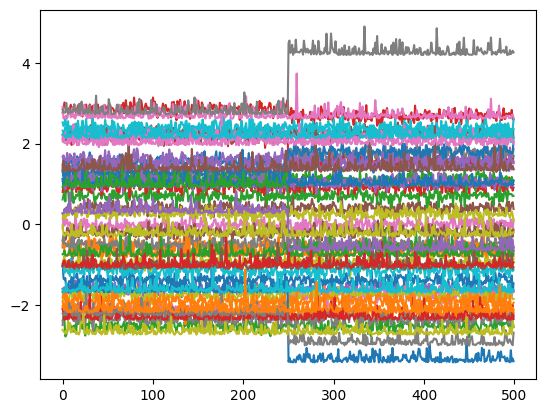

In [163]:
# Base center for the clusters
base_center = list(np.random.uniform(-3, 3, 50))  
n_clusters = 2
n_samples = 500
np.random.seed(10)
varying_features = np.random.choice(50,10,replace=False)  

# Generate dataset with Laplace distribution (heavy tails)
X, y, centers = make_dynamic_blobs(
    n_samples=n_samples, 
    base_center=base_center, 
    n_clusters=n_clusters, 
    varying_features=varying_features, 
    cluster_std=0.1, 
    center_offset_range=(-2, 2), 
    distribution=["normal"] * 30 + ["exponential"] * 20,
    random_state=420
)

# Plot the results
fig, ax = plt.subplots()
pd.DataFrame(X).plot(ax=ax, legend=False)
plt.show()

x_tensor = torch.Tensor(X[:250,:])
y_tensor = torch.Tensor(X[250:,:])

Text(0, 0.5, 'Abs diff Beta per removal')

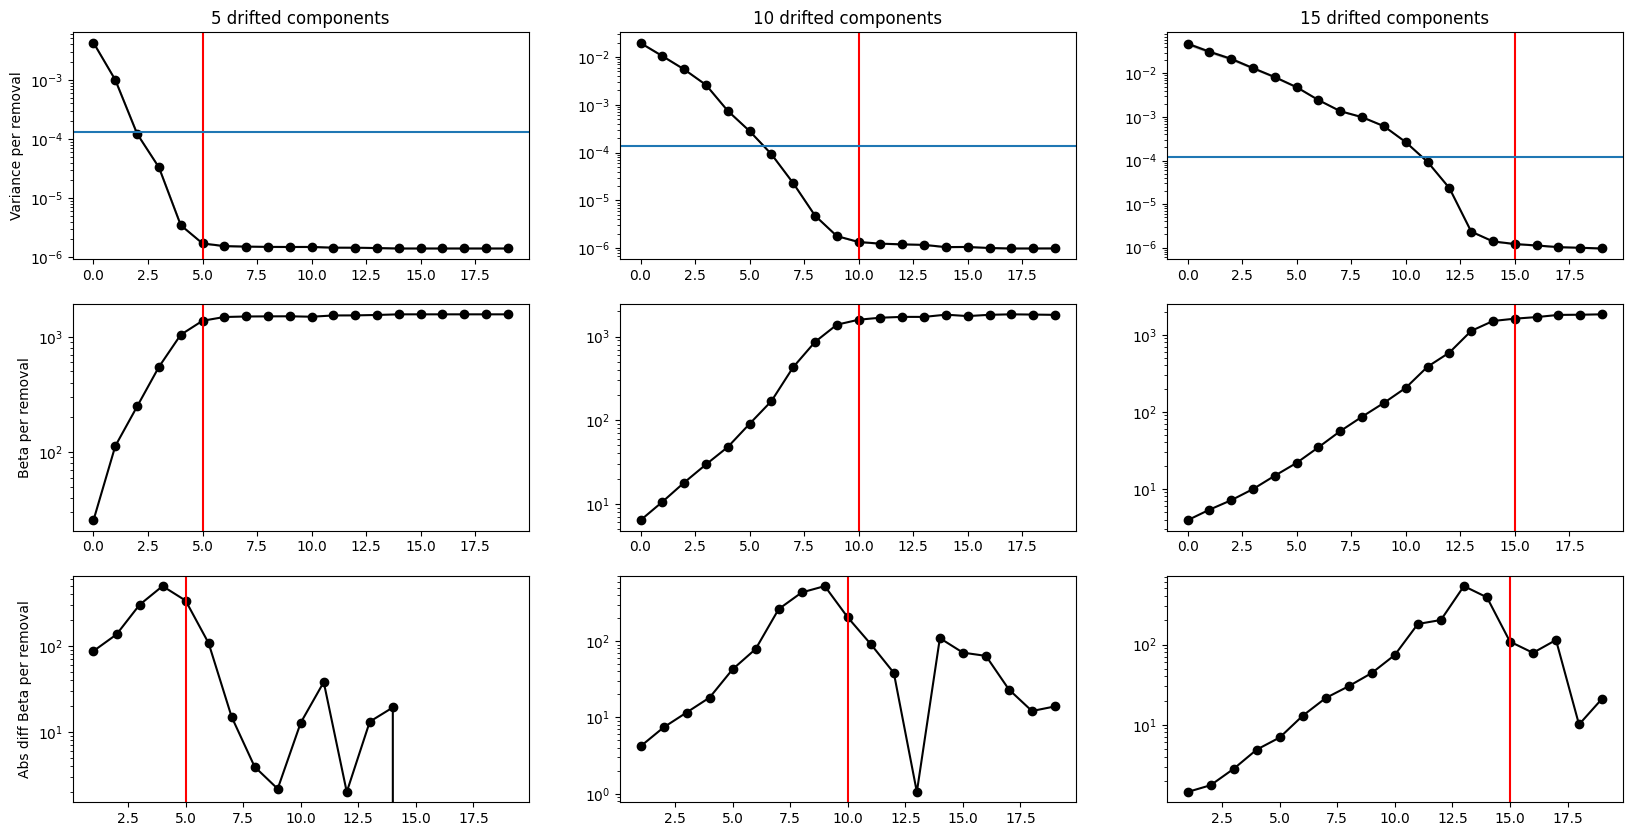

In [283]:

# Base center for the clusters

Dim = 30
base_center = list(np.random.uniform(-3, 3, Dim))  
n_clusters = 2
n_samples = 1000
np.random.seed(0)
std= 0.4

fig, ax = plt.subplots(3,3,figsize=(20,10))
for row_ind, varying_dim in enumerate([5,10,15]):

    varying_features = np.random.choice(Dim,varying_dim,replace=False)  

    # # Plot the results
    # fig, ax = plt.subplots()
    # pd.DataFrame(X).plot(ax=ax, legend=False)
    # plt.show()


    VARS = {}
    BETAS = {}
    ALPHAS = {}
    for i in [0,1,2,3,4]:
        VARS[i] = []
        BETAS[i] = []
        ALPHAS[i]=[]
        
        X,y ,_ = make_dynamic_blobs(
        n_samples=n_samples, 
        base_center=base_center, 
        n_clusters=n_clusters, 
        varying_features=varying_features, 
        cluster_std=std, 
        center_offset_range=(-1, 1), 
        distribution=["normal"] * Dim + ["exponential"] * 0,
        random_state=i
    )
        x_tensor = torch.Tensor(X[:int(n_samples/2),:])
        y_tensor = torch.Tensor(X[int(n_samples/2):,:])
        rfs, _ = remove_important_features_syn(x_tensor,y_tensor,20,1000,q=0.95)

        # var = []
        # Bs = []
        # As = []
        for d in rfs:
            alph = d['alpha']
            b = d['beta']
            #print(alph/b**2)
            VARS[i].append(alph/b**2)
            BETAS[i].append(b)
            ALPHAS[i].append(alph)

    df_alpha = pd.DataFrame(ALPHAS)
    df_beta = pd.DataFrame(BETAS)

    vars = pd.DataFrame(df_alpha/(df_beta)**2)
    ax[0,row_ind].set_title(f"{varying_dim} drifted components")
    ax[0,row_ind].plot(vars.mean(axis=1),marker="o",c='black')
    ax[0,row_ind].fill_between(range(len(vars)),vars.mean(axis=1)-2*vars.var(axis=1),vars.mean(axis=1)+2*vars.var(axis=1),alpha=0.2,color='black')
    ax[0,row_ind].set_yscale('log')
    ax[0,row_ind].axvline(x=varying_dim,c='red')
    ax[0,row_ind].axhline((x_tensor**2).var(axis=0).sum()/Dim**2/n_samples+(y_tensor**2).var(axis=0).sum()/Dim**2/n_samples)#2*(2*std**2)/(Dim*(n_samples/2)))
#2*(std**2*Dim/Dim**2/500))
    #
    pd.DataFrame((df_beta.mean(axis=1))).diff().abs().plot(ax=ax[2,row_ind],marker='o',c='black',legend=False)
    ax[2,row_ind].set_yscale('log')
    ax[2,row_ind].axvline(x=varying_dim,c='red')


    #pd.DataFrame(np.array(Bs)).pct_change().plot(ax=ax[2],marker='o')
    #ax[2].set_yscale('log')

    ax[1,row_ind].plot(df_beta.mean(axis=1),marker='o',c='black')
    ax[1,row_ind].set_yscale('log')
    ax[1,row_ind].axvline(x=varying_dim,c='red')

ax[0,0].set_ylabel(f"Variance per removal")
ax[1,0].set_ylabel(f"Beta per removal")
ax[2,0].set_ylabel(f"Abs diff Beta per removal")


In [305]:
### verteilung von projections?

THETA = sample_theta_torch(x_tensor,1000)

def project(X, Y, theta, p,device='cpu'):
    X ,Y, theta= X.to(device),Y.to(device), theta.T.to(device)

    x_proj = torch.matmul(X, theta)
    y_proj = torch.matmul(Y, theta)


    qs = torch.linspace(0, 1, 100, device=device)

    # Compute quantiles for x_proj and y_proj
    xp_quantiles = torch.quantile(x_proj, qs, dim=0, interpolation="linear")
    yp_quantiles = torch.quantile(y_proj, qs, dim=0, interpolation="linear")

    # Calculate the p-distance between quantiles
    dist_p = torch.pow(torch.abs(xp_quantiles - yp_quantiles),p)

    return x_proj,y_proj,dist_p.mean(axis=0)


XP,YP,dist_p= project(x_tensor,y_tensor,THETA,2)

dist_p.var()

tensor(0.1127)

In [304]:
print(VARS)

{0: [0.025686299680114003, 0.013452158216040384, 0.007931063120424797, 0.0043718570099009904, 0.0011427737465818236, 0.0006457922849738897, 0.0001931116322978506, 9.423260781227573e-05, 4.885231404671223e-05, 3.1259087144271915e-05, 1.5594113423252717e-05, 9.40383102584566e-06, 5.22745725349214e-06, 2.625951943934608e-06, 1.3452565016692038e-06, 1.0997030527321006e-06, 1.0184700809454704e-06, 9.207663542369209e-07, 9.12324100858646e-07, 8.898154245179907e-07], 1: [0.04758649177743271, 0.03403355958338815, 0.020704036136573983, 0.0132024138715698, 0.007923884098972444, 0.004248087513825195, 0.0028052329585526218, 0.0012955520258465824, 0.000859189270873128, 0.00039156237396940723, 0.00012620741762659108, 3.4282336812793355e-05, 1.2394813259870851e-05, 3.202639978933862e-06, 1.2503356426967058e-06, 1.0962154473065129e-06, 1.0192792415478631e-06, 9.236913354536025e-07, 8.505143881034641e-07, 7.585047463091799e-07], 2: [0.01706764556751584, 0.007247016108998971, 0.003887077998207778, 0.001

In [306]:
wp_approx = []

for i in range(XP.shape[1]):

    wp_approx.append(((XP[:,i].mean()-YP[:,i].mean())**2+(XP[:,i].std()-YP[:,i].std())**2)**0.5)

np.var(wp_approx)

0.08497881

(array([7.423e+03, 1.572e+03, 5.650e+02, 2.580e+02, 1.170e+02, 3.600e+01,
        1.600e+01, 7.000e+00, 2.000e+00, 4.000e+00]),
 array([3.69877060e-04, 3.26130807e-01, 6.51891708e-01, 9.77652669e-01,
        1.30341363e+00, 1.62917447e+00, 1.95493543e+00, 2.28069639e+00,
        2.60645723e+00, 2.93221831e+00, 3.25797915e+00]),
 <BarContainer object of 10 artists>)

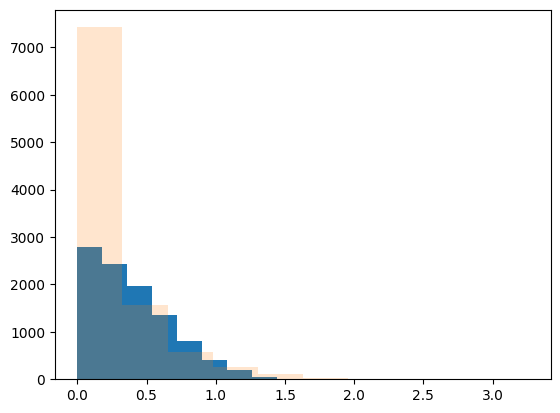

In [297]:
plt.hist(wp_approx)
plt.hist(dist_p,alpha=0.2)

In [183]:
(x_tensor**2).var(axis=0).sum()/Dim**2/n_samples+(y_tensor**2).var(axis=0).sum()/Dim**2/n_samples

tensor(0.0004)

In [225]:
def get_cov(x):
    return pd.DataFrame(x.numpy()).cov().to_numpy()

def op_norm(cov,p):
    return np.linalg.svd(cov,compute_uv=False)[0]**(p/2)

In [312]:
cov = get_cov(x_tensor)
op_1 = op_norm(cov,2)

cov = get_cov(y_tensor)
op_2 = op_norm(cov,2)


(op_1+op_2)**2

0.22071133528048806

In [147]:
kd = 2*(Dim-1)/(Dim**2*(Dim+2))
kd

0.00019411764705882354

In [239]:
1/n_samples*n_samples/(2*n_samples)

0.001

In [151]:
vars

,0,1,2,3,4
0,2.135770,4.143207,1.221916,3.012401,6.757817
1,1.190230,2.735701,0.520036,2.113860,5.204658
2,0.673563,1.597081,0.281257,1.874749,3.625759
3,0.347943,0.983644,0.152499,1.202330,2.574833
4,0.111010,0.639042,0.077598,0.652670,1.707341
5,0.035408,0.346683,0.033763,0.318384,1.052547
6,0.016662,0.191323,0.016931,0.127956,0.760608
7,0.006115,0.070243,0.005509,0.047393,0.484553
8,0.002280,0.038535,0.003017,0.026950,0.241107
9,0.001110,0.016017,0.001361,0.009972,0.128286


In [6]:
pd.DataFrame(BETAS).mean(axis=1)

0      255.292633
1      916.132385
2     1307.532349
3     1716.627808
4     2777.335693
5     3322.925293
6     3512.430664
7     3698.193848
8     3878.818848
9     3956.498047
10    4008.650879
11    4008.650879
12    4008.650879
13    4008.650879
14    4008.650879
15    4008.650879
16    4008.650879
17    4008.650879
18    4008.650879
19    4008.650879
20    4008.650879
21    4008.650879
22    4008.650879
23    4008.650879
24    4008.650879
25    4008.650879
26    4008.650879
27    4008.650879
28    4008.650879
29    4008.650879
dtype: float32

<Axes: >

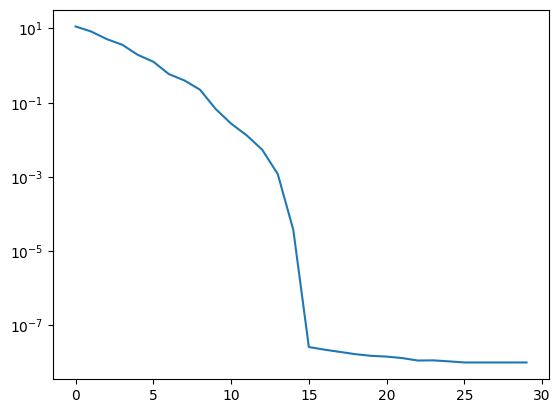

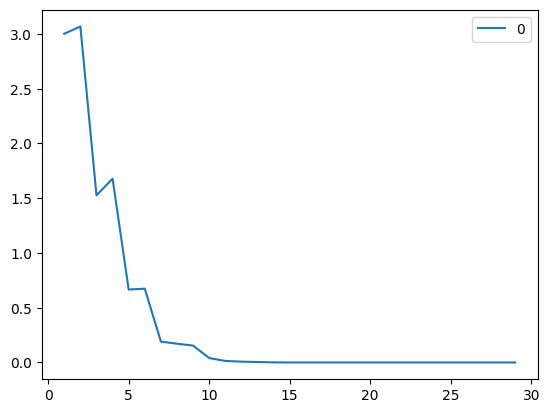

In [ ]:

plt.plot(np.array(As)/np.array(Bs)**2)
plt.yscale('log')
pd.DataFrame(np.array(As)/np.array(Bs)**2).diff().abs().plot()

In [132]:
pd.DataFrame(np.array(As)/np.array(Bs)**2).diff()

,0
0,NaN
1,-1.545217e+00
2,-8.796683e-01
3,-5.766481e-01
4,-1.164967e-01
5,-4.028126e-02
6,-1.422982e-02
7,-7.842283e-03
8,-4.204286e-03
9,-1.139093e-03


In [95]:
4/np.sqrt((1000*50))

0.01788854381999832

(array([634., 195.,  65.,  45.,  28.,  12.,  10.,   7.,   2.,   2.]),
 array([2.36434116e-07, 4.94412147e-02, 9.88821930e-02, 1.48323171e-01,
        1.97764150e-01, 2.47205128e-01, 2.96646106e-01, 3.46087084e-01,
        3.95528063e-01, 4.44969041e-01, 4.94410019e-01]),
 <BarContainer object of 10 artists>)

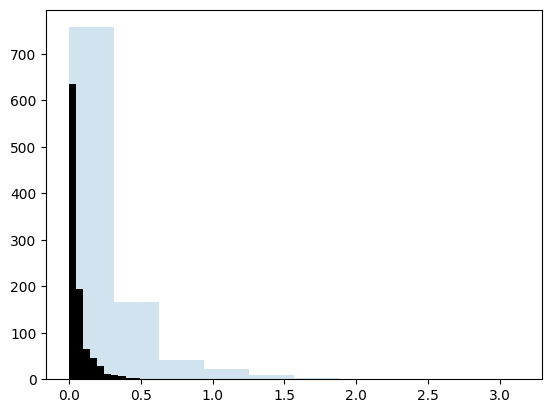

In [57]:
a1,b1 = rfs[0]['alpha'],rfs[0]['beta']
a2,b2 = rfs[3]['alpha'],rfs[3]['beta']


Sample1 = np.random.gamma(a1,1/b1,1000)
Sample2 = np.random.gamma(a2,1/b2,1000)

plt.hist(Sample1,alpha=0.2)
plt.hist(Sample2,color='black')

In [59]:
a2/b2**2

0.006389570853518279

(array([109., 266., 271., 174.,  89.,  47.,  28.,   7.,   7.,   2.]),
 array([0.00013105, 0.0009255 , 0.00171994, 0.00251438, 0.00330883,
        0.00410327, 0.00489772, 0.00569216, 0.00648661, 0.00728105,
        0.0080755 ]),
 <BarContainer object of 10 artists>)

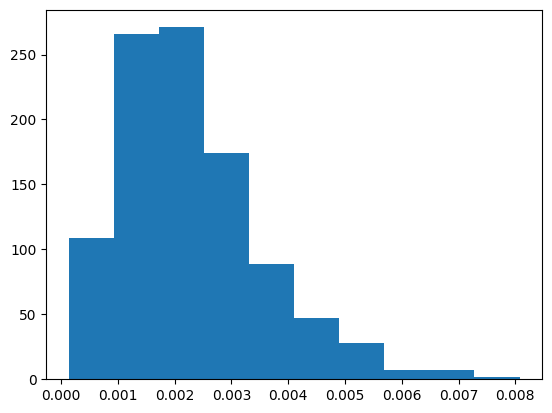

In [56]:
plt.hist(Sample2)